# Análisis multivariado descriptivo de variables categóricas

## 0. Setup

In [1]:
# %pip install lightgbm optuna

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pathlib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

plt.rcParams['figure.dpi'] = 110

print('Imports OK')

Imports OK


## 1. Carga de datos

In [3]:
#df = pd.read_csv('dataset_7000_53.csv')

df = pd.read_csv("dataset_4913_53.csv") #dataset con target sin NA

print(f'Shape: {df.shape}')
print(f"n_shows_24_25 — con dato: {df['n_shows_24_25'].notna().sum()}  "
      f"sin dato: {df['n_shows_24_25'].isna().sum()}")
df[['artist_name','sp_monthly_listeners','ins_followers','n_shows_24_25']].head(3)

Shape: (4913, 53)
n_shows_24_25 — con dato: 4913  sin dato: 0


,artist_name,sp_monthly_listeners,ins_followers,n_shows_24_25
0,Bad Bunny,112734492.0,54721804.0,45
1,Taylor Swift,102733014.0,280531827.0,49
2,Bruno Mars,134166866.0,42922145.0,55


# dimensiones variables


In [4]:
# Agrupación conceptual de variables
# Construcción de diccionario de variables

id_cols = [
    "chartmetric_id",
    "artist_name"
]

metadata_cols = [
    "country",
    "country_short",
    "pronoun_title",
    "pronoun_short",
    "record_label",
    "major_record_label",
    "primary_genre",
    "genre_short",
    "band",
    "muerto_disuelto"
]

streaming_cols = [
    "sp_followers",
    "sp_monthly_listeners",
    "sp_popularity",
    "deezer_fans",
    "shazam_count",
    "pandora_lifetime_streams",
    "pandora_lifetime_stations_added"
]

playlist_cols = [
    "sp_playlist_total_reach",
    "num_sp_editorial_playlists",
    "num_sp_playlists",
    "sp_editorial_playlist_total_reach",
    "num_am_editorial_playlists",
    "num_am_playlists",
    "num_de_editorial_playlists",
    "num_de_playlists",
    "de_playlist_total_reach",
    "de_editorial_playlist_total_reach",
    "num_az_editorial_playlists",
    "num_az_playlists",
    "num_yt_editorial_playlists",
    "num_yt_playlists",
    "yt_playlist_total_reach"
]

social_cols = [
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_likes",
    "tiktok_top_video_views",
    "tiktok_top_video_comments",
    "tiktok_track_posts"
]

youtube_cols = [
    "ycs_subscribers",
    "ycs_views",
    "youtube_daily_video_views",
    "youtube_monthly_video_views"
]

live_cols = [
    "n_shows_24_25",
    "n_shows_with_capacity_24_25",
    "capacity_24_25",
    "avg_venue_capacity_24_25",
    "n_cities_24_25",
    "n_countries_24_25",
    "shows_per_country_24_25",
    "off_cycle"
]


# Diccionario de dimensiones
column_groups = {
    "identificacion": id_cols,
    "metadata": metadata_cols,
    "streaming": streaming_cols,
    "playlists": playlist_cols,
    "redes_sociales": social_cols,
    "youtube": youtube_cols,
    "live_events": live_cols
}

# ============================================================
# Tabla auxiliar con identidad conceptual de cada variable
# ============================================================

variable_dimension = []

for dimension, cols in column_groups.items():
    for col in cols:
        variable_dimension.append({
            "variable": col,
            "dimension": dimension
        })

df_variable_dimension = pd.DataFrame(variable_dimension)

# ============================================================
# Control de cobertura de columnas
# ============================================================

grouped_cols = df_variable_dimension["variable"].tolist()

cols_in_groups_not_in_df = sorted(set(grouped_cols) - set(df.columns))
cols_in_df_not_in_groups = sorted(set(df.columns) - set(grouped_cols))

print("Columnas del df:", df.shape[1])
print("Columnas agrupadas:", len(grouped_cols))
print("Columnas agrupadas que no están en df:", cols_in_groups_not_in_df)
print("Columnas del df no agrupadas:", cols_in_df_not_in_groups)

# ============================================================
# Resumen por dimensión
# ============================================================

resumen_dimensiones = (
    df_variable_dimension
    .groupby("dimension", as_index=False)
    .agg(n_variables=("variable", "count"))
    .sort_values("n_variables", ascending=False)
)

display(resumen_dimensiones)

# ============================================================
# Vista del diccionario de variables
# ============================================================

display(df_variable_dimension)

Columnas del df: 53
Columnas agrupadas: 53
Columnas agrupadas que no están en df: []
Columnas del df no agrupadas: []


,dimension,n_variables
3,playlists,15
2,metadata,10
1,live_events,8
5,streaming,7
4,redes_sociales,7
6,youtube,4
0,identificacion,2


,variable,dimension
0,chartmetric_id,identificacion
1,artist_name,identificacion
2,country,metadata
3,country_short,metadata
4,pronoun_title,metadata
5,pronoun_short,metadata
6,record_label,metadata
7,major_record_label,metadata
8,primary_genre,metadata
9,genre_short,metadata


# tipos datos

In [5]:
# 1. Definir el diccionario de tipos

# agregar los ratios en el diccionario

dtypes_dict = {
    'chartmetric_id': 'Int64',
    'artist_name': 'str',
    'country': 'category',
    'pronoun_title': 'category',
    'record_label': 'category',
    'primary_genre': 'category',
    'sp_followers': 'Int64',
    'sp_monthly_listeners': 'Int64',
    'sp_popularity': 'float64',
    'sp_playlist_total_reach': 'float64',
    'ins_followers': 'Int64',
    'twitter_followers': 'Int64',
    'tiktok_followers': 'Int64',
    'tiktok_likes': 'Int64',
    'ycs_subscribers': 'Int64',
    'ycs_views': 'Int64',
    'youtube_daily_video_views': 'Int64',
    'youtube_monthly_video_views': 'Int64',
    'deezer_fans': 'Int64',
    'shazam_count': 'Int64',
    'pandora_lifetime_streams': 'Int64',
    'pandora_lifetime_stations_added': 'Int64',
    'band': 'bool',
    'num_sp_editorial_playlists': 'Int64',
    'num_sp_playlists': 'Int64',
    'sp_editorial_playlist_total_reach': 'float64',
    'num_am_editorial_playlists': 'Int64',
    'num_am_playlists': 'Int64',
    'num_de_editorial_playlists': 'Int64',
    'num_de_playlists': 'Int64',
    'de_playlist_total_reach': 'float64',
    'de_editorial_playlist_total_reach': 'float64',
    'num_az_editorial_playlists': 'Int64',
    'num_az_playlists': 'Int64',
    'num_yt_editorial_playlists': 'Int64',
    'num_yt_playlists': 'Int64',
    'yt_playlist_total_reach': 'float64',
    'tiktok_top_video_views': 'float64',
    'tiktok_top_video_comments': 'float64',
    'tiktok_track_posts': 'float64',
    'n_shows_24_25': 'Int64',
    'n_shows_with_capacity_24_25': 'Int64',
    'capacity_24_25': 'float64',
    'avg_venue_capacity_24_25': 'float64',
    'n_cities_24_25': 'Int64',
    'n_countries_24_25': 'Int64',
    'shows_per_country_24_25': 'float64',
    'major_record_label': 'boolean',
    'pronoun_short': 'category',
    'genre_short': 'category',
    'country_short': 'category',
    'off_cycle': 'bool',
    'muerto_disuelto': 'boolean'
}

# Aplicar la conversión al dataframe df

# Conversión solo de columnas existentes
dtypes_presentes = {
    col: dtype
    for col, dtype in dtypes_dict.items()
    if col in df.columns
}

df = df.astype(dtypes_presentes)

# 3. Verificación rápida
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   chartmetric_id                     4913 non-null   Int64   
 1   artist_name                        4913 non-null   str     
 2   country                            4909 non-null   category
 3   pronoun_title                      4913 non-null   category
 4   record_label                       4604 non-null   category
 5   primary_genre                      4913 non-null   category
 6   sp_followers                       4907 non-null   Int64   
 7   sp_monthly_listeners               4907 non-null   Int64   
 8   sp_popularity                      4911 non-null   float64 
 9   sp_playlist_total_reach            4913 non-null   float64 
 10  ins_followers                      4580 non-null   Int64   
 11  twitter_followers                  3968 non-null   Int

In [6]:
# Estructura general del dataset
print("Filas y columnas:", df.shape)

# Control de clave única
print("Artistas únicos:", df["chartmetric_id"].nunique())
print("Duplicados por chartmetric_id:", df.duplicated(subset="chartmetric_id").sum())

# Control de target
print("Nulos en target:", df["n_shows_24_25"].isna().sum())
print("Tipo de dato de target:", df["n_shows_24_25"].dtype)

Filas y columnas: (4913, 53)
Artistas únicos: 4913
Duplicados por chartmetric_id: 0
Nulos en target: 0
Tipo de dato de target: Int64


In [7]:
# ============================================================
# Parámetros del análisis categórico multivariado
# ============================================================

from itertools import combinations

target_shows = "n_shows_24_25"
target_log1p_shows = "log1p_n_shows_24_25"

variables_categoricas_candidatas = [
    "genre_short",
    "country_short",
    "major_record_label",
    "band",
    "pronoun_short"
]

umbral_minimo_artistas_por_celda = 20

directorio_tablas_categoricas = pathlib.Path("tablas_categoricas")
directorio_tablas_categoricas.mkdir(exist_ok=True)

df_categoricas_target = df.copy()

df_categoricas_target[target_log1p_shows] = np.log1p(
    df_categoricas_target[target_shows].astype(float)
)

for variable_categorica in variables_categoricas_candidatas:
    df_categoricas_target[variable_categorica] = (
        df_categoricas_target[variable_categorica]
        .astype("object")
        .where(df_categoricas_target[variable_categorica].notna(), "Sin dato")
        .astype(str)
    )

mediana_global_shows = df_categoricas_target[target_shows].median()
mediana_global_log1p_shows = df_categoricas_target[target_log1p_shows].median()
pct_global_cero_shows = (df_categoricas_target[target_shows].eq(0).mean() * 100)

print("Dataset de trabajo:", df_categoricas_target.shape)
print("Target:", target_shows)
print("Mediana global shows:", mediana_global_shows)
print("Mediana global log1p shows:", round(mediana_global_log1p_shows, 4))
print("Porcentaje global de ceros:", round(pct_global_cero_shows, 2))

Dataset de trabajo: (4913, 54)
Target: n_shows_24_25
Mediana global shows: 13.0
Mediana global log1p shows: 2.6391
Porcentaje global de ceros: 17.5


In [8]:
# ============================================================
# Sanity check de variables categóricas candidatas
# ============================================================

columnas_faltantes_categoricas = [
    variable_categorica
    for variable_categorica in variables_categoricas_candidatas
    if variable_categorica not in df_categoricas_target.columns
]

if len(columnas_faltantes_categoricas) > 0:
    raise ValueError(f"Columnas faltantes: {columnas_faltantes_categoricas}")

resumen_variables_categoricas = []

for variable_categorica in variables_categoricas_candidatas:
    resumen_variables_categoricas.append({
        "variable": variable_categorica,
        "n_categorias": df_categoricas_target[variable_categorica].nunique(),
        "n_sin_dato": (df_categoricas_target[variable_categorica] == "Sin dato").sum(),
        "pct_sin_dato": round(
            (df_categoricas_target[variable_categorica] == "Sin dato").mean() * 100,
            2
        )
    })

tabla_sanity_variables_categoricas = pd.DataFrame(resumen_variables_categoricas)

tabla_sanity_variables_categoricas

,variable,n_categorias,n_sin_dato,pct_sin_dato
0,genre_short,12,0,0.00
1,country_short,7,4,0.08
2,major_record_label,3,309,6.29
3,band,2,0,0.00
4,pronoun_short,4,0,0.00


In [9]:
# ============================================================
# Función general para evaluar combinaciones categóricas
# ============================================================

def evaluar_combinaciones_categoricas_vs_target(
    dataframe_base,
    variables_combinacion,
    target_shows,
    target_log1p_shows,
    mediana_global_shows,
    umbral_minimo_artistas_por_celda=20
):
    variables_combinacion = list(variables_combinacion)
    
    columnas_necesarias = variables_combinacion + [
        target_shows,
        target_log1p_shows
    ]
    
    columnas_faltantes = [
        columna
        for columna in columnas_necesarias
        if columna not in dataframe_base.columns
    ]
    
    if len(columnas_faltantes) > 0:
        raise ValueError(f"Columnas faltantes: {columnas_faltantes}")
    
    tabla_combinacion = (
        dataframe_base
        .groupby(variables_combinacion, dropna=False, observed=True)
        .agg(
            n_artistas=(target_shows, "size"),
            mediana_shows=(target_shows, "median"),
            p75_shows=(target_shows, lambda serie: serie.quantile(0.75)),
            pct_cero_shows=(target_shows, lambda serie: serie.eq(0).mean() * 100),
            mediana_log1p_shows=(target_log1p_shows, "median")
        )
        .reset_index()
    )
    
    tabla_combinacion = tabla_combinacion[
        tabla_combinacion["n_artistas"] >= umbral_minimo_artistas_por_celda
    ].copy()
    
    if mediana_global_shows == 0:
        tabla_combinacion["lift_mediana_vs_global"] = np.nan
    else:
        tabla_combinacion["lift_mediana_vs_global"] = (
            tabla_combinacion["mediana_shows"] / mediana_global_shows
        )
    
    tabla_combinacion["variables_combinadas"] = " + ".join(variables_combinacion)
    
    tabla_combinacion["combinacion"] = (
        tabla_combinacion[variables_combinacion]
        .astype(str)
        .agg(" | ".join, axis=1)
    )
    
    tabla_combinacion = tabla_combinacion.sort_values(
        by=["lift_mediana_vs_global", "n_artistas"],
        ascending=[False, False]
    ).reset_index(drop=True)
    
    tabla_combinacion["ranking_lift_descendente"] = np.arange(
        1,
        len(tabla_combinacion) + 1
    )
    
    tabla_combinacion["ranking_lift_ascendente"] = (
        tabla_combinacion["lift_mediana_vs_global"]
        .rank(method="first", ascending=True)
        .astype(int)
    )
    
    columnas_ordenadas = (
        ["variables_combinadas", "combinacion"]
        + variables_combinacion
        + [
            "n_artistas",
            "mediana_shows",
            "p75_shows",
            "pct_cero_shows",
            "mediana_log1p_shows",
            "lift_mediana_vs_global",
            "ranking_lift_descendente",
            "ranking_lift_ascendente"
        ]
    )
    
    return tabla_combinacion[columnas_ordenadas]

In [10]:
# ============================================================
# Evaluación de pares y tríos de variables categóricas
# ============================================================

lista_tablas_pares_categoricos = []
lista_tablas_trios_categoricos = []

for variables_par in combinations(variables_categoricas_candidatas, 2):
    tabla_par_actual = evaluar_combinaciones_categoricas_vs_target(
        dataframe_base=df_categoricas_target,
        variables_combinacion=variables_par,
        target_shows=target_shows,
        target_log1p_shows=target_log1p_shows,
        mediana_global_shows=mediana_global_shows,
        umbral_minimo_artistas_por_celda=umbral_minimo_artistas_por_celda
    )
    
    lista_tablas_pares_categoricos.append(tabla_par_actual)

for variables_trio in combinations(variables_categoricas_candidatas, 3):
    tabla_trio_actual = evaluar_combinaciones_categoricas_vs_target(
        dataframe_base=df_categoricas_target,
        variables_combinacion=variables_trio,
        target_shows=target_shows,
        target_log1p_shows=target_log1p_shows,
        mediana_global_shows=mediana_global_shows,
        umbral_minimo_artistas_por_celda=umbral_minimo_artistas_por_celda
    )
    
    lista_tablas_trios_categoricos.append(tabla_trio_actual)

tabla_pares_categoricos_vs_target = pd.concat(
    lista_tablas_pares_categoricos,
    ignore_index=True
)

tabla_trios_categoricos_vs_target = pd.concat(
    lista_tablas_trios_categoricos,
    ignore_index=True
)

tabla_pares_categoricos_vs_target = tabla_pares_categoricos_vs_target.sort_values(
    by=["lift_mediana_vs_global", "n_artistas"],
    ascending=[False, False]
).reset_index(drop=True)

tabla_trios_categoricos_vs_target = tabla_trios_categoricos_vs_target.sort_values(
    by=["lift_mediana_vs_global", "n_artistas"],
    ascending=[False, False]
).reset_index(drop=True)

print("Pares evaluados:", tabla_pares_categoricos_vs_target.shape)
print("Tríos evaluados:", tabla_trios_categoricos_vs_target.shape)

Pares evaluados: (188, 15)
Tríos evaluados: (391, 15)


In [11]:
# ============================================================
# Rankings de combinaciones más altas y más bajas
# ============================================================

top_n_combinaciones = 25

tabla_top_pares_categoricos = tabla_pares_categoricos_vs_target.head(
    top_n_combinaciones
).copy()

tabla_bottom_pares_categoricos = (
    tabla_pares_categoricos_vs_target
    .sort_values(
        by=["lift_mediana_vs_global", "n_artistas"],
        ascending=[True, False]
    )
    .head(top_n_combinaciones)
    .copy()
)

tabla_top_trios_categoricos = tabla_trios_categoricos_vs_target.head(
    top_n_combinaciones
).copy()

tabla_bottom_trios_categoricos = (
    tabla_trios_categoricos_vs_target
    .sort_values(
        by=["lift_mediana_vs_global", "n_artistas"],
        ascending=[True, False]
    )
    .head(top_n_combinaciones)
    .copy()
)

tabla_top_pares_categoricos

,variables_combinadas,combinacion,genre_short,country_short,n_artistas,mediana_shows,p75_shows,pct_cero_shows,mediana_log1p_shows,lift_mediana_vs_global,ranking_lift_descendente,ranking_lift_ascendente,major_record_label,band,pronoun_short
0,genre_short + major_record_label,Country & folk | True,Country & folk,NaN,71,65.0,89.0,7.042254,4.189655,5.0,1,30,True,NaN,NaN
1,genre_short + pronoun_short,Country & folk | he/him,Country & folk,NaN,167,61.0,89.0,13.173653,4.127134,4.692308,1,31,NaN,NaN,he/him
2,genre_short + band,Country & folk | False,Country & folk,NaN,203,57.0,88.5,12.807882,4.060443,4.384615,1,23,NaN,False,NaN
3,genre_short + country_short,Country & folk | North America,Country & folk,North America,236,56.0,88.25,13.135593,4.042897,4.307692,1,39,NaN,NaN,NaN
4,genre_short + major_record_label,Country & folk | False,Country & folk,NaN,177,50.0,87.0,14.124294,3.931826,3.846154,2,29,False,NaN,NaN
5,genre_short + pronoun_short,Country & folk | they/them,Country & folk,NaN,61,50.0,82.0,13.114754,3.931826,3.846154,2,30,NaN,NaN,they/them
6,genre_short + band,Country & folk | True,Country & folk,NaN,62,48.0,81.5,12.903226,3.890987,3.692308,2,22,NaN,True,NaN
7,genre_short + band,Rock & metal | True,Rock & metal,NaN,371,39.0,67.5,19.137466,3.688879,3.0,3,21,NaN,True,NaN
8,genre_short + country_short,Rock & metal | North America,Rock & metal,North America,326,39.0,71.75,23.312883,3.688879,3.0,2,38,NaN,NaN,NaN
9,genre_short + pronoun_short,Country & folk | she/her,Country & folk,NaN,37,39.0,79.0,10.810811,3.688879,3.0,3,29,NaN,NaN,she/her


In [12]:
# ============================================================
# Guardado de tablas del análisis categórico multivariado
# ============================================================

ruta_pares_completos = directorio_tablas_categoricas / "pares_categoricos_vs_n_shows_24_25.csv"
ruta_trios_completos = directorio_tablas_categoricas / "trios_categoricos_vs_n_shows_24_25.csv"
ruta_top_pares = directorio_tablas_categoricas / "top_pares_categoricos_vs_n_shows_24_25.csv"
ruta_bottom_pares = directorio_tablas_categoricas / "bottom_pares_categoricos_vs_n_shows_24_25.csv"
ruta_top_trios = directorio_tablas_categoricas / "top_trios_categoricos_vs_n_shows_24_25.csv"
ruta_bottom_trios = directorio_tablas_categoricas / "bottom_trios_categoricos_vs_n_shows_24_25.csv"
ruta_excel_resumen = directorio_tablas_categoricas / "resumen_lifts_categoricos_vs_n_shows_24_25.xlsx"

tabla_pares_categoricos_vs_target.to_csv(ruta_pares_completos, index=False)
tabla_trios_categoricos_vs_target.to_csv(ruta_trios_completos, index=False)
tabla_top_pares_categoricos.to_csv(ruta_top_pares, index=False)
tabla_bottom_pares_categoricos.to_csv(ruta_bottom_pares, index=False)
tabla_top_trios_categoricos.to_csv(ruta_top_trios, index=False)
tabla_bottom_trios_categoricos.to_csv(ruta_bottom_trios, index=False)

with pd.ExcelWriter(ruta_excel_resumen) as writer:
    tabla_top_pares_categoricos.to_excel(writer, sheet_name="top_pares", index=False)
    tabla_bottom_pares_categoricos.to_excel(writer, sheet_name="bottom_pares", index=False)
    tabla_top_trios_categoricos.to_excel(writer, sheet_name="top_trios", index=False)
    tabla_bottom_trios_categoricos.to_excel(writer, sheet_name="bottom_trios", index=False)
    tabla_pares_categoricos_vs_target.to_excel(writer, sheet_name="pares_completos", index=False)
    tabla_trios_categoricos_vs_target.to_excel(writer, sheet_name="trios_completos", index=False)

print("Tablas guardadas en:", directorio_tablas_categoricas)

Tablas guardadas en: tablas_categoricas


In [13]:
# ============================================================
# Sanity check final de resultados
# ============================================================

resumen_resultados_lifts = pd.DataFrame({
    "tabla": [
        "pares",
        "trios"
    ],
    "n_filas": [
        len(tabla_pares_categoricos_vs_target),
        len(tabla_trios_categoricos_vs_target)
    ],
    "n_combinaciones_variables": [
        tabla_pares_categoricos_vs_target["variables_combinadas"].nunique(),
        tabla_trios_categoricos_vs_target["variables_combinadas"].nunique()
    ],
    "lift_maximo": [
        tabla_pares_categoricos_vs_target["lift_mediana_vs_global"].max(),
        tabla_trios_categoricos_vs_target["lift_mediana_vs_global"].max()
    ],
    "lift_minimo": [
        tabla_pares_categoricos_vs_target["lift_mediana_vs_global"].min(),
        tabla_trios_categoricos_vs_target["lift_mediana_vs_global"].min()
    ],
    "umbral_minimo_artistas_por_celda": [
        umbral_minimo_artistas_por_celda,
        umbral_minimo_artistas_por_celda
    ]
})

resumen_resultados_lifts

,tabla,n_filas,n_combinaciones_variables,lift_maximo,lift_minimo,umbral_minimo_artistas_por_celda
0,pares,188,10,5.000000,0.0,20
1,trios,391,10,5.230769,0.0,20


In [14]:
tabla_top_trios_categoricos

,variables_combinadas,combinacion,genre_short,country_short,major_record_label,n_artistas,mediana_shows,p75_shows,pct_cero_shows,mediana_log1p_shows,lift_mediana_vs_global,ranking_lift_descendente,ranking_lift_ascendente,band,pronoun_short
0,genre_short + country_short + major_record_label,Country & folk | North America | True,Country & folk,North America,True,61,68.0,96.0,4.918033,4.234107,5.230769,1,55,NaN,NaN
1,genre_short + major_record_label + band,Country & folk | True | False,Country & folk,NaN,True,58,68.0,98.25,5.172414,4.234107,5.230769,1,46,False,NaN
2,genre_short + major_record_label + pronoun_short,Country & folk | True | he/him,Country & folk,NaN,True,53,68.0,96.0,5.660377,4.234107,5.230769,1,55,NaN,he/him
3,genre_short + country_short + pronoun_short,Country & folk | North America | he/him,Country & folk,North America,NaN,148,62.0,89.25,13.513514,4.143135,4.769231,1,59,NaN,he/him
4,genre_short + band + pronoun_short,Country & folk | False | he/him,Country & folk,NaN,NaN,167,61.0,89.0,13.173653,4.127134,4.692308,1,31,False,he/him
5,genre_short + country_short + band,Country & folk | North America | False,Country & folk,North America,NaN,184,59.0,89.0,13.043478,4.094206,4.538462,1,50,False,NaN
6,genre_short + major_record_label + pronoun_short,Country & folk | False | he/him,Country & folk,NaN,False,104,55.0,85.75,16.346154,4.025352,4.230769,2,54,NaN,he/him
7,genre_short + country_short + major_record_label,Country & folk | North America | False,Country & folk,North America,False,159,52.0,87.5,15.09434,3.970292,4.0,2,54,NaN,NaN
8,genre_short + country_short + band,Country & folk | North America | True,Country & folk,North America,NaN,52,52.0,87.0,13.461538,3.970292,4.0,2,49,True,NaN
9,genre_short + country_short + pronoun_short,Country & folk | North America | they/them,Country & folk,North America,NaN,51,52.0,87.0,13.72549,3.970292,4.0,2,58,NaN,they/them


In [15]:
tabla_bottom_pares_categoricos

,variables_combinadas,combinacion,genre_short,country_short,n_artistas,mediana_shows,p75_shows,pct_cero_shows,mediana_log1p_shows,lift_mediana_vs_global,ranking_lift_descendente,ranking_lift_ascendente,major_record_label,band,pronoun_short
181,genre_short + band,Jazz & blues & classical | False,Jazz & blues & classical,NaN,121,0.0,4.0,66.115702,0.000000,0.0,23,1,NaN,False,NaN
182,genre_short + pronoun_short,Jazz & blues & classical | he/him,Jazz & blues & classical,NaN,112,0.0,2.5,68.75,0.000000,0.0,31,1,NaN,NaN,he/him
183,genre_short + major_record_label,Jazz & blues & classical | False,Jazz & blues & classical,NaN,79,0.0,13.0,58.227848,0.000000,0.0,28,1,False,NaN,NaN
184,genre_short + country_short,Jazz & blues & classical | North America,Jazz & blues & classical,North America,62,0.0,27.75,54.83871,0.000000,0.0,38,1,NaN,NaN,NaN
185,genre_short + country_short,Jazz & blues & classical | Europe_sinGB,Jazz & blues & classical,Europe_sinGB,54,0.0,0.75,74.074074,0.000000,0.0,39,2,NaN,NaN,NaN
186,genre_short + major_record_label,Jazz & blues & classical | True,Jazz & blues & classical,NaN,46,0.0,2.0,67.391304,0.000000,0.0,29,2,True,NaN,NaN
187,genre_short + major_record_label,Rock & metal | Sin dato,Rock & metal,NaN,28,0.0,5.75,53.571429,0.000000,0.0,30,3,Sin dato,NaN,NaN
176,major_record_label + band,Sin dato | True,NaN,NaN,139,1.0,16.0,46.76259,0.693147,0.076923,6,1,Sin dato,True,NaN
177,major_record_label + pronoun_short,Sin dato | they/them,NaN,NaN,137,1.0,15.0,47.445255,0.693147,0.076923,9,1,Sin dato,NaN,they/them
178,genre_short + major_record_label,Pop | Sin dato,Pop,NaN,67,1.0,16.5,46.268657,0.693147,0.076923,26,4,Sin dato,NaN,NaN


In [16]:
tabla_bottom_pares_categoricos

,variables_combinadas,combinacion,genre_short,country_short,n_artistas,mediana_shows,p75_shows,pct_cero_shows,mediana_log1p_shows,lift_mediana_vs_global,ranking_lift_descendente,ranking_lift_ascendente,major_record_label,band,pronoun_short
181,genre_short + band,Jazz & blues & classical | False,Jazz & blues & classical,NaN,121,0.0,4.0,66.115702,0.000000,0.0,23,1,NaN,False,NaN
182,genre_short + pronoun_short,Jazz & blues & classical | he/him,Jazz & blues & classical,NaN,112,0.0,2.5,68.75,0.000000,0.0,31,1,NaN,NaN,he/him
183,genre_short + major_record_label,Jazz & blues & classical | False,Jazz & blues & classical,NaN,79,0.0,13.0,58.227848,0.000000,0.0,28,1,False,NaN,NaN
184,genre_short + country_short,Jazz & blues & classical | North America,Jazz & blues & classical,North America,62,0.0,27.75,54.83871,0.000000,0.0,38,1,NaN,NaN,NaN
185,genre_short + country_short,Jazz & blues & classical | Europe_sinGB,Jazz & blues & classical,Europe_sinGB,54,0.0,0.75,74.074074,0.000000,0.0,39,2,NaN,NaN,NaN
186,genre_short + major_record_label,Jazz & blues & classical | True,Jazz & blues & classical,NaN,46,0.0,2.0,67.391304,0.000000,0.0,29,2,True,NaN,NaN
187,genre_short + major_record_label,Rock & metal | Sin dato,Rock & metal,NaN,28,0.0,5.75,53.571429,0.000000,0.0,30,3,Sin dato,NaN,NaN
176,major_record_label + band,Sin dato | True,NaN,NaN,139,1.0,16.0,46.76259,0.693147,0.076923,6,1,Sin dato,True,NaN
177,major_record_label + pronoun_short,Sin dato | they/them,NaN,NaN,137,1.0,15.0,47.445255,0.693147,0.076923,9,1,Sin dato,NaN,they/them
178,genre_short + major_record_label,Pop | Sin dato,Pop,NaN,67,1.0,16.5,46.268657,0.693147,0.076923,26,4,Sin dato,NaN,NaN


In [17]:
tabla_bottom_trios_categoricos

,variables_combinadas,combinacion,genre_short,country_short,major_record_label,n_artistas,mediana_shows,p75_shows,pct_cero_shows,mediana_log1p_shows,lift_mediana_vs_global,ranking_lift_descendente,ranking_lift_ascendente,band,pronoun_short
373,genre_short + band + pronoun_short,Jazz & blues & classical | False | he/him,Jazz & blues & classical,NaN,NaN,110,0.0,1.75,70.0,0.000000,0.0,31,1,False,he/him
374,genre_short + major_record_label + band,Jazz & blues & classical | False | False,Jazz & blues & classical,NaN,False,68,0.0,1.5,67.647059,0.000000,0.0,44,1,False,NaN
375,genre_short + major_record_label + pronoun_short,Jazz & blues & classical | False | he/him,Jazz & blues & classical,NaN,False,62,0.0,1.0,69.354839,0.000000,0.0,53,1,NaN,he/him
376,genre_short + country_short + band,Jazz & blues & classical | North America | False,Jazz & blues & classical,North America,NaN,53,0.0,10.0,62.264151,0.000000,0.0,49,1,False,NaN
377,genre_short + country_short + band,Jazz & blues & classical | Europe_sinGB | False,Jazz & blues & classical,Europe_sinGB,NaN,51,0.0,0.0,78.431373,0.000000,0.0,50,2,False,NaN
378,genre_short + country_short + pronoun_short,Jazz & blues & classical | Europe_sinGB | he/him,Jazz & blues & classical,Europe_sinGB,NaN,49,0.0,0.0,79.591837,0.000000,0.0,58,1,NaN,he/him
379,genre_short + country_short + pronoun_short,Jazz & blues & classical | North America | he...,Jazz & blues & classical,North America,NaN,49,0.0,8.0,63.265306,0.000000,0.0,59,2,NaN,he/him
380,genre_short + major_record_label + band,Jazz & blues & classical | True | False,Jazz & blues & classical,NaN,True,44,0.0,2.5,68.181818,0.000000,0.0,45,2,False,NaN
381,genre_short + major_record_label + pronoun_short,Jazz & blues & classical | True | he/him,Jazz & blues & classical,NaN,True,42,0.0,1.75,71.428571,0.000000,0.0,54,2,NaN,he/him
382,genre_short + major_record_label + band,Pop | Sin dato | True,Pop,NaN,Sin dato,41,0.0,7.0,53.658537,0.000000,0.0,46,3,True,NaN


# graficos

In [18]:
# ============================================================
# Directorio de gráficos para análisis categórico multivariado
# ============================================================

directorio_graficos_categoricos = pathlib.Path("graficos_categoricos")
directorio_graficos_categoricos.mkdir(exist_ok=True)

print("Directorio de gráficos:", directorio_graficos_categoricos)

Directorio de gráficos: graficos_categoricos


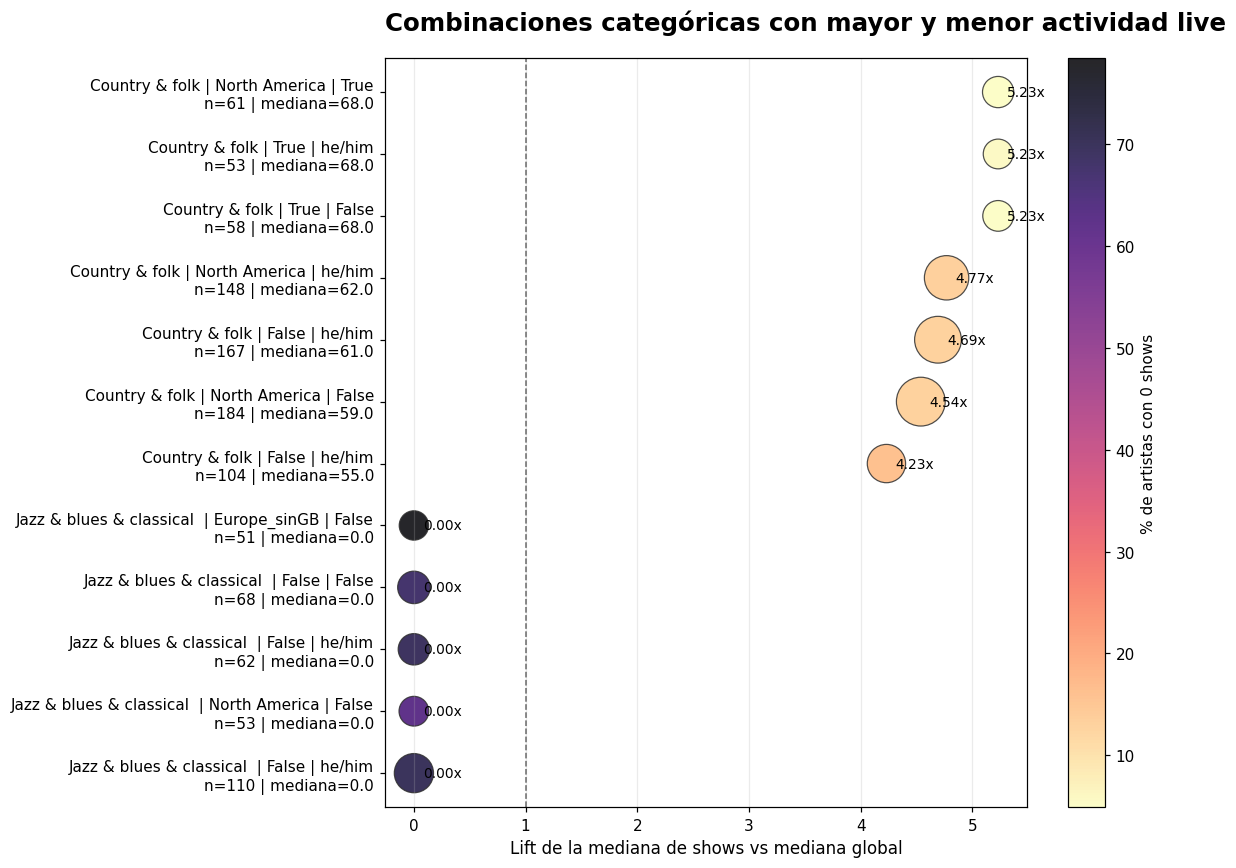

Gráfico guardado en: graficos_categoricos\ranking_editorial_lifts_top_bottom_trios.png


In [19]:
# ============================================================
# Figura editorial de combinaciones categóricas top y bottom
# ============================================================

cantidad_top_combinaciones_grafico = 7
cantidad_bottom_combinaciones_grafico = 5

tabla_top_trios_para_grafico = tabla_trios_categoricos_vs_target.head(
    cantidad_top_combinaciones_grafico
).copy()

tabla_bottom_trios_para_grafico = (
    tabla_trios_categoricos_vs_target
    .sort_values(
        by=["lift_mediana_vs_global", "n_artistas"],
        ascending=[True, False]
    )
    .head(cantidad_bottom_combinaciones_grafico)
    .copy()
)

tabla_ranking_editorial_lifts = pd.concat(
    [
        tabla_top_trios_para_grafico.assign(tipo_hallazgo="Top lift"),
        tabla_bottom_trios_para_grafico.assign(tipo_hallazgo="Bottom lift")
    ],
    ignore_index=True
)

tabla_ranking_editorial_lifts["etiqueta_grafico"] = (
    tabla_ranking_editorial_lifts["combinacion"]
    + "\n"
    + "n="
    + tabla_ranking_editorial_lifts["n_artistas"].astype(str)
    + " | mediana="
    + tabla_ranking_editorial_lifts["mediana_shows"].round(1).astype(str)
)

tabla_ranking_editorial_lifts = tabla_ranking_editorial_lifts.sort_values(
    by="lift_mediana_vs_global",
    ascending=True
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 8))

tamanios_puntos = (
    tabla_ranking_editorial_lifts["n_artistas"] / 
    tabla_ranking_editorial_lifts["n_artistas"].max()
) * 900 + 120

scatter = ax.scatter(
    tabla_ranking_editorial_lifts["lift_mediana_vs_global"],
    tabla_ranking_editorial_lifts["etiqueta_grafico"],
    s=tamanios_puntos,
    c=tabla_ranking_editorial_lifts["pct_cero_shows"],
    cmap="magma_r",
    alpha=0.85,
    edgecolor="#2F2F2F",
    linewidth=0.8
)

ax.axvline(
    x=1,
    color="#2F2F2F",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

ax.set_title(
    "Combinaciones categóricas con mayor y menor actividad live",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=18
)

ax.set_xlabel("Lift de la mediana de shows vs mediana global", fontsize=11)
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.25)

barra_color = plt.colorbar(scatter, ax=ax)
barra_color.set_label("% de artistas con 0 shows", fontsize=10)

for indice_fila, fila in tabla_ranking_editorial_lifts.iterrows():
    ax.text(
        fila["lift_mediana_vs_global"] + 0.08,
        indice_fila,
        f"{fila['lift_mediana_vs_global']:.2f}x",
        va="center",
        fontsize=9
    )

plt.tight_layout()

ruta_grafico_ranking_editorial = (
    directorio_graficos_categoricos /
    "ranking_editorial_lifts_top_bottom_trios.png"
)

plt.savefig(
    ruta_grafico_ranking_editorial,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico guardado en:", ruta_grafico_ranking_editorial)

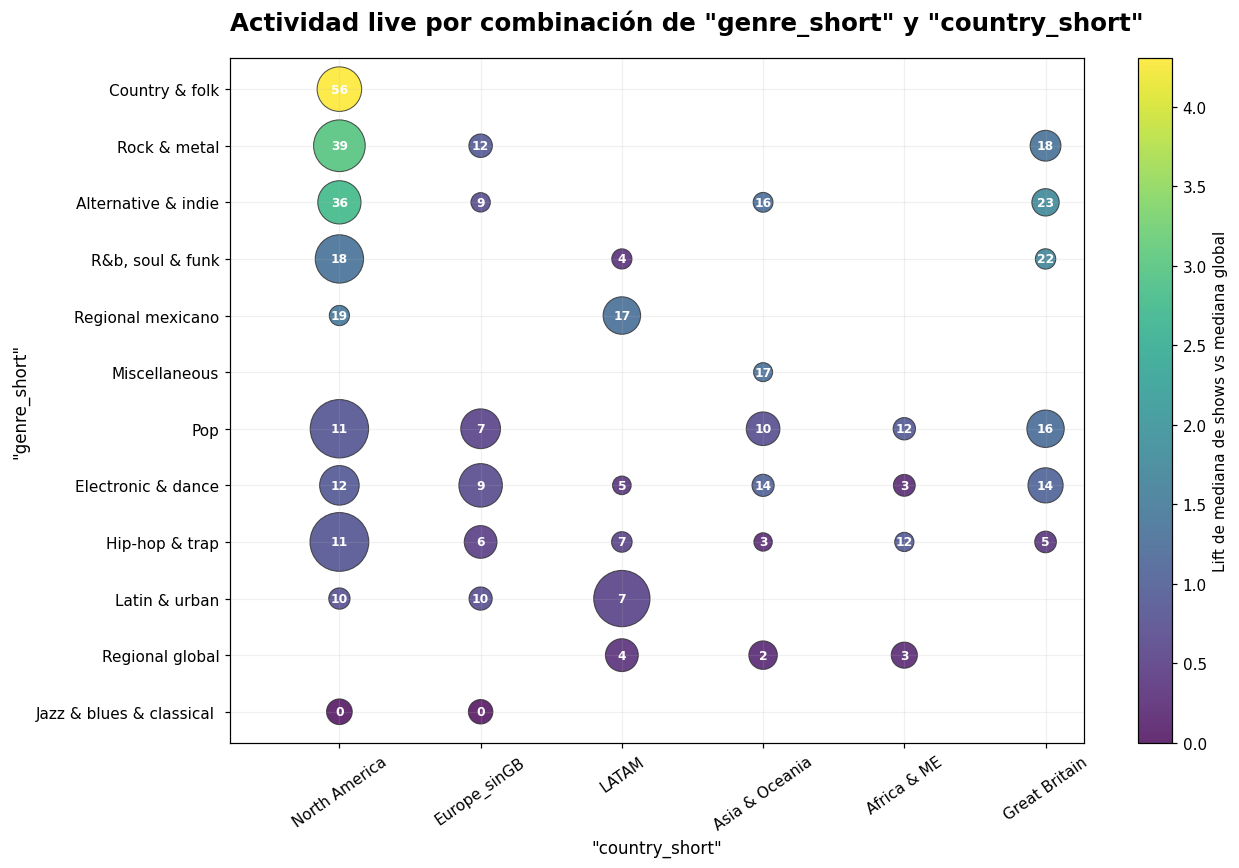

Gráfico guardado en: graficos_categoricos\bubble_heatmap_genre_short_country_short_lifts.png


In [20]:
# ============================================================
# Bubble heatmap de genre_short x country_short
# ============================================================

tabla_genero_region_lifts = tabla_pares_categoricos_vs_target[
    tabla_pares_categoricos_vs_target["variables_combinadas"] == "genre_short + country_short"
].copy()

orden_generos_por_lift_maximo = (
    tabla_genero_region_lifts
    .groupby("genre_short")["lift_mediana_vs_global"]
    .max()
    .sort_values(ascending=True)
    .index
    .tolist()
)

orden_regiones_por_lift_maximo = (
    tabla_genero_region_lifts
    .groupby("country_short")["lift_mediana_vs_global"]
    .max()
    .sort_values(ascending=False)
    .index
    .tolist()
)

tabla_genero_region_lifts["genre_short"] = pd.Categorical(
    tabla_genero_region_lifts["genre_short"],
    categories=orden_generos_por_lift_maximo,
    ordered=True
)

tabla_genero_region_lifts["country_short"] = pd.Categorical(
    tabla_genero_region_lifts["country_short"],
    categories=orden_regiones_por_lift_maximo,
    ordered=True
)

tabla_genero_region_lifts = tabla_genero_region_lifts.sort_values(
    by=["genre_short", "country_short"]
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))

tamanios_burbujas = (
    tabla_genero_region_lifts["n_artistas"] /
    tabla_genero_region_lifts["n_artistas"].max()
) * 1400 + 80

scatter = ax.scatter(
    tabla_genero_region_lifts["country_short"],
    tabla_genero_region_lifts["genre_short"],
    s=tamanios_burbujas,
    c=tabla_genero_region_lifts["lift_mediana_vs_global"],
    cmap="viridis",
    alpha=0.82,
    edgecolor="#2F2F2F",
    linewidth=0.7
)

for _, fila in tabla_genero_region_lifts.iterrows():
    ax.text(
        fila["country_short"],
        fila["genre_short"],
        f"{fila['mediana_shows']:.0f}",
        ha="center",
        va="center",
        fontsize=8,
        color="white",
        fontweight="bold"
    )

ax.axvline(
    x=-0.5,
    color="white",
    linewidth=0
)

ax.set_title(
    'Actividad live por combinación de "genre_short" y "country_short"',
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=18
)

ax.set_xlabel('"country_short"', fontsize=11)
ax.set_ylabel('"genre_short"', fontsize=11)

ax.tick_params(axis="x", rotation=35)
ax.grid(alpha=0.18)

barra_color = plt.colorbar(scatter, ax=ax)
barra_color.set_label("Lift de mediana de shows vs mediana global", fontsize=10)

plt.tight_layout()

ruta_grafico_bubble_heatmap_genero_region = (
    directorio_graficos_categoricos /
    "bubble_heatmap_genre_short_country_short_lifts.png"
)

plt.savefig(
    ruta_grafico_bubble_heatmap_genero_region,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico guardado en:", ruta_grafico_bubble_heatmap_genero_region)

In [21]:
# ============================================================
# Sanity check de tablas usadas en gráficos
# ============================================================

sanity_graficos_categoricos = pd.DataFrame({
    "grafico": [
        "ranking_editorial_top_bottom_trios",
        "bubble_heatmap_genre_short_country_short"
    ],
    "n_filas_usadas": [
        len(tabla_ranking_editorial_lifts),
        len(tabla_genero_region_lifts)
    ],
    "lift_minimo": [
        tabla_ranking_editorial_lifts["lift_mediana_vs_global"].min(),
        tabla_genero_region_lifts["lift_mediana_vs_global"].min()
    ],
    "lift_maximo": [
        tabla_ranking_editorial_lifts["lift_mediana_vs_global"].max(),
        tabla_genero_region_lifts["lift_mediana_vs_global"].max()
    ],
    "n_minimo_artistas": [
        tabla_ranking_editorial_lifts["n_artistas"].min(),
        tabla_genero_region_lifts["n_artistas"].min()
    ]
})

sanity_graficos_categoricos

,grafico,n_filas_usadas,lift_minimo,lift_maximo,n_minimo_artistas
0,ranking_editorial_top_bottom_trios,12,0.0,5.230769,51
1,bubble_heatmap_genre_short_country_short,39,0.0,4.307692,20
